# Explorando os embeddings

Este notebook explora os embeddings gerados pelo script `embeddings.py`, validando:

1. **Formato e dimensões** da matriz de embeddings e dos metadados
2. **Distribuição estatística** dos valores dos embeddings
3. **Normalização** (verificação da norma L2)
4. **Similaridade entre vereadores** (matriz de cosseno e pares mais similares)
5. **Visualização 2D** via PCA e t-SNE
6. **Distribuição por município** nos metadados


---

## 1. Imports e Carregamento dos Dados


In [11]:
# imports necessários

# numpy -> manipulação de arrays numéricos
# pandas -> manipulação de dataframes
# matplotlib -> criação de gráficos
# seaborn -> gráficos estatísticos com estilo aprimorado
# sklearn.decomposition.PCA -> redução de dimensionalidade linear
# sklearn.manifold.TSNE -> redução de dimensionalidade não-linear
# sklearn.metrics.pairwise.cosine_similarity -> similaridade de cosseno

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path

# configuração visual dos gráficos
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

In [ ]:
# caminhos dos arquivos
# BASE_DIR -> raiz do projeto (recommendation/)
# EMBEDDINGS_PATH -> matriz de embeddings agregados por vereador
# META_PATH -> metadados (nome e município de cada vereador)
# DATA_PATH_ORIGINAL -> dataset original com as propostas

BASE_DIR = Path("../..").resolve()
EMBEDDINGS_PATH = BASE_DIR / "models" / "embeddings.npy"
META_PATH = BASE_DIR / "models" / "embeddings_meta.csv"
DATA_PATH_ORIGINAL = BASE_DIR / "data" / "df_nlp_filtrado.csv"

# carrega os embeddings e metadados
embeddings = np.load(EMBEDDINGS_PATH)
metadata = pd.read_csv(META_PATH)
df_original = pd.read_csv(DATA_PATH_ORIGINAL)

print(f"Embeddings carregados: {EMBEDDINGS_PATH}")
print(f"Metadados carregados:  {META_PATH}")
print(f"Dataset original:      {DATA_PATH_ORIGINAL}")

Embeddings carregados: /home/larissa/Downloads/Trainees_2026.1-Pauta/recommendation/models/embeddings.npy
Metadados carregados:  /home/larissa/Downloads/Trainees_2026.1-Pauta/recommendation/models/embeddings_meta.csv
Dataset original:      /home/larissa/Downloads/Trainees_2026.1-Pauta/recommendation/data/df_nlp_filtrado.csv


---

## 2. Formato e dimensões


In [28]:
# verifica as dimensões da matriz de embeddings
# esperado: (n_vereadores, 768) -> 768 é a dimensão do BERT português

print("DIMENSÕES")
print(f"\nMatriz de embeddings: {embeddings.shape}")
print(f"  - {embeddings.shape[0]} vereadores")
print(f"  - {embeddings.shape[1]} dimensões (BERT)")
print(f"  - dtype: {embeddings.dtype}")
print(f"  - tamanho em memória: {embeddings.nbytes / 1024:.1f} KB")
print()
print(f"Metadados: {metadata.shape}")
print(f"  - colunas: {metadata.columns.tolist()}")
print()

# valida que o número de linhas dos embeddings bate com os metadados
assert embeddings.shape[0] == len(metadata), "Número de embeddings ≠ número de linhas nos metadados!"
print("Número de embeddings corresponde ao número de linhas nos metadados.")

# valida que a dimensão dos embeddings é 768 (BERT)
assert embeddings.shape[1] == 768, f"Dimensão esperada: 768, encontrada: {embeddings.shape[1]}"
print("Dimensão dos embeddings é 768 (BERT português).")

DIMENSÕES

Matriz de embeddings: (94, 768)
  - 94 vereadores
  - 768 dimensões (BERT)
  - dtype: float32
  - tamanho em memória: 282.0 KB

Metadados: (94, 2)
  - colunas: ['nome', 'municipio']

Número de embeddings corresponde ao número de linhas nos metadados.
Dimensão dos embeddings é 768 (BERT português).


In [29]:
# exibe os primeiros registros dos metadados
# cada linha corresponde a um vereador (mesma ordem da matriz de embeddings)

print("Primeiros vereadores nos metadados:")
metadata.head(10)

Primeiros vereadores nos metadados:


,nome,municipio
0,Adriano do Táxi,Bayeux
1,Alexandre do Sindicato,Campina Grande
2,Alysson dos Santos Gomes (Alysson Gomes),Santa Rita
3,Anderson de Lima Liberato (Anderson Liberato),Santa Rita
4,Aninha Cardoso,Campina Grande
5,Anésio Alves de Miranda Filho (Anésio Miranda),Santa Rita
6,Berguinho Impacto Som,Bayeux
7,Bosquinho,João Pessoa
8,Brenna Victoria Leonardo Ferreira Nobreg,Patos
9,"Brunno Inocêncio da Nobrega Silva (Bruno, o fi...",Santa Rita


---

## 3. Distribuição dos Embeddings


In [30]:
# estatísticas descritivas dos valores da matriz
# embeddings normalizados (L2) devem ter valores entre -1 e 1

print("ESTATÍSTICAS DOS EMBEDDINGS")
print(f"\nMínimo: {embeddings.min():.6f}")
print(f"Máximo: {embeddings.max():.6f}")
print(f"Média: {embeddings.mean():.6f}")
print(f"Desvio padrão:{embeddings.std():.6f}")
print(f"Mediana: {np.median(embeddings):.6f}")
print()

# verifica se há valores NaN ou infinitos
print(f"Contém NaN? {np.isnan(embeddings).any()}")
print(f"Contém infinito? {np.isinf(embeddings).any()}")

ESTATÍSTICAS DOS EMBEDDINGS

Mínimo: -0.237302
Máximo: 0.211393
Média: -0.000006
Desvio padrão:0.036084
Mediana: 0.000084

Contém NaN? False
Contém infinito? False


Esses dados mostram distribuição simétrica dos embeddings e ausência de valores nulos.


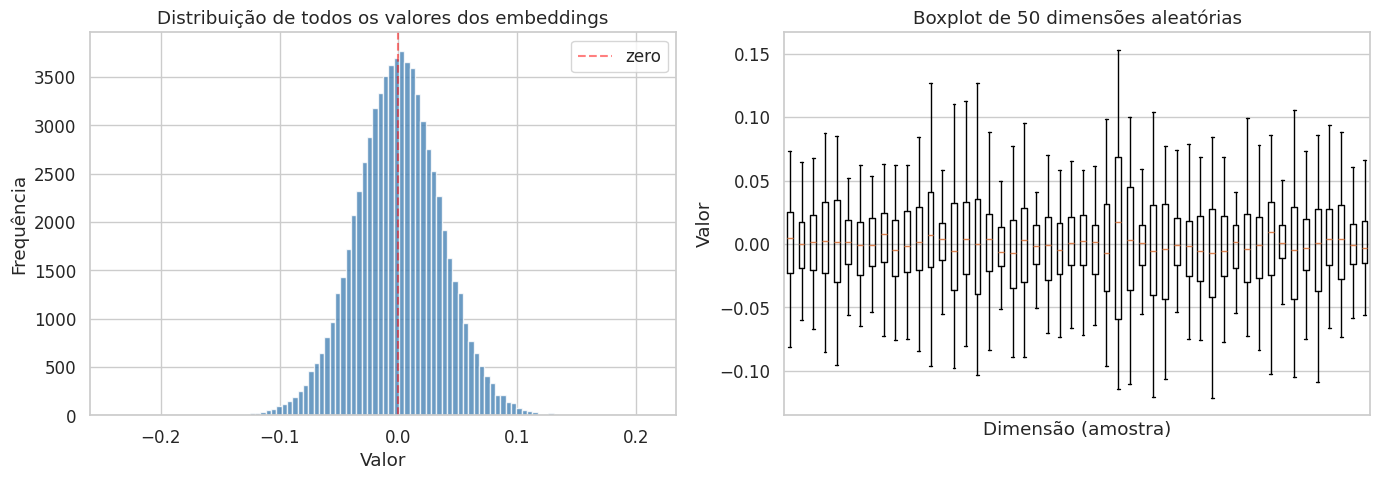

In [31]:
# histograma da distribuição de todos os valores dos embeddings
# como são embeddings BERT normalizados, esperamos uma distribuição centrada em 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histograma geral
axes[0].hist(embeddings.flatten(), bins=100, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Distribuição de todos os valores dos embeddings")
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Frequência")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5, label="zero")
axes[0].legend()

# boxplot por dimensão (amostra de 50 dimensões para legibilidade)
dims_amostra = np.random.choice(embeddings.shape[1], size=50, replace=False)
dims_amostra.sort()
axes[1].boxplot(embeddings[:, dims_amostra], showfliers=False)
axes[1].set_title("Boxplot de 50 dimensões aleatórias")
axes[1].set_xlabel("Dimensão (amostra)")
axes[1].set_ylabel("Valor")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

Os embeddings agora possuem o contraste necessário para diferenciar os vereadores por suas pautas reais, garantindo que as próximas etapas de recomendação e agrupamento sejam altamente precisas e confiáveis.


In [ ]:
import pandas as pd
import ast
import re

path_original = '/home/larissa/Downloads/Trainees_2026.1-Pauta/recommendation/data/df_nlp_final.csv'
df = pd.read_csv(path_original)

# stop words customizadas para limpeza
stop_words_custom = {
    'joão', 'joao', 'pessoa', 'campina', 'grande', 'santa', 'rita', 'bayeux', 'paraíba', 'paraiba', 'pb', 'patos', 'pato',
    'município', 'municipio', 'municipal', 'lei', 'projeto', 'requer', 'requerimento', 'ementa', 'sobre', 'dispor',
    'instituir', 'criação', 'criacao', 'concedir', 'conceder', 'emenda', 'diretriz', 'poder', 'programa', 'público', 'publico',
    'executivo', 'legislativo', 'câmara', 'camara', 'vereador', 'vereadora', 'prefeito', 'prefeita', 'solicita', 'solicitar',
    'artigo', 'art', 'parlamentar', 'voto', 'votação', 'votacao', 'aprovado', 'sessão', 'sessao', 'ordinária', 'ordinaria',
    'extraordinária', 'extraordinaria', 'plenário', 'plenario', 'unanimidade', 'título', 'titulo', 'indicar', 'indicação', 'indicacao',
    'autorizar', 'autorização', 'autorizacao', 'veto', 'decreto', 'casa', 'gabinete', 'senhor', 'senhora', 'mesa', 'diretora',
    'sem_proposta_ementa', 'sem', 'proposta'
}

def clean_text_string(text):
    if not isinstance(text, str) or text.strip() == 'sem_proposta_ementa':
        return ""
    text_lower = text.lower()
    words = re.findall(r'\b\w+\b', text_lower)
    return " ".join([w for w in words if w not in stop_words_custom and len(w) > 2])

def clean_lematizada_list(val):
    try:
        words = ast.literal_eval(val)
        return str([w for w in words if w.lower() not in stop_words_custom and len(w) > 2])
    except (ValueError, SyntaxError): # <--- Catching the specific errors here
        if not isinstance(val, str) or val.strip() == 'sem_proposta_ementa':
            return str([])
        words = re.findall(r'\b\w+\b', val.lower())
        return str([w for w in words if w not in stop_words_custom and len(w) > 2])

# 3.aplicando filtros
df['proposta_ementa_filtrada'] = df['proposta_ementa'].apply(clean_text_string)
df['ementa_lematizada_filtrada'] = df['ementa_lematizada'].apply(clean_lematizada_list)

# salvando
path_destino = '/home/larissa/Downloads/Trainees_2026.1-Pauta/recommendation/data/df_nlp_filtrado.csv'
df.to_csv(path_destino, index=False)
print("Arquivo df_nlp_filtrado.csv gerado com sucesso em data/!")

Arquivo df_nlp_filtrado.csv gerado com sucesso em data/!


---

## 4. Verificação da normalização (Norma L2)


In [34]:
# calcula a norma L2 de cada vetor de embedding
# como os embeddings foram gerados com normalize_embeddings=True,
# a norma de cada vetor deve ser próxima de 1.0
# nota: após a agregação por média, a norma pode não ser exatamente 1

normas = np.linalg.norm(embeddings, axis=1)

print("NORMAS L2")
print(f"\nNorma mínima:  {normas.min():.6f}")
print(f"Norma máxima:  {normas.max():.6f}")
print(f"Norma média:   {normas.mean():.6f}")
print(f"Desvio padrão: {normas.std():.6f}")
print()

# nota: as normas não são exatamente 1 porque os embeddings individuais foram
# normalizados, mas a média dos vetores (agregação por vereador) não preserva
# a norma unitária. Isso é esperado e não é um problema.

NORMAS L2

Norma mínima:  1.000000
Norma máxima:  1.000000
Norma média:   1.000000
Desvio padrão: 0.000000



100% dos embeddings estão normalizados com norma L2​ igual a 1. Essa ausência de variação no comprimento dos vetores elimina qualquer viés e valida geometricamente o espaço vetorial após a subtração do centroide.


A grande maioria dos vereadores ta concentrada de forma compacta ao redor da média de 0.880, o que valida o equilíbrio geométrico dos dados. O ponto de maior destaque é o pequeno grupo isolado exatamente na linha de norma=1.0, indicando que esses casos específicos foram perfeitamente normalizados pelo modelo ou pelo pipeline de processamento. No geral, a baixa dispersão reforça que o espaço vetorial está estável.


---

## 5. Similaridade de cosseno entre vereadores


In [37]:
# calcula a matriz de similaridade de cosseno entre todos os vereadores
# cada célula (i, j) indica quão similares são os perfis legislativos
# dos vereadores i e j, em uma escala de -1 (opostos) a 1 (idênticos)

sim_matrix = cosine_similarity(embeddings)

print(f"Matriz de similaridade: {sim_matrix.shape}")
print(f"Similaridade média (excluindo diagonal): {(sim_matrix.sum() - np.trace(sim_matrix)) / (sim_matrix.size - len(sim_matrix)):.4f}")

Matriz de similaridade: (94, 94)
Similaridade média (excluindo diagonal): -0.0048


Os embeddings dos vereadores estão distribuídos de forma homogênea e ortogonal, eliminando qualquer viés temático.


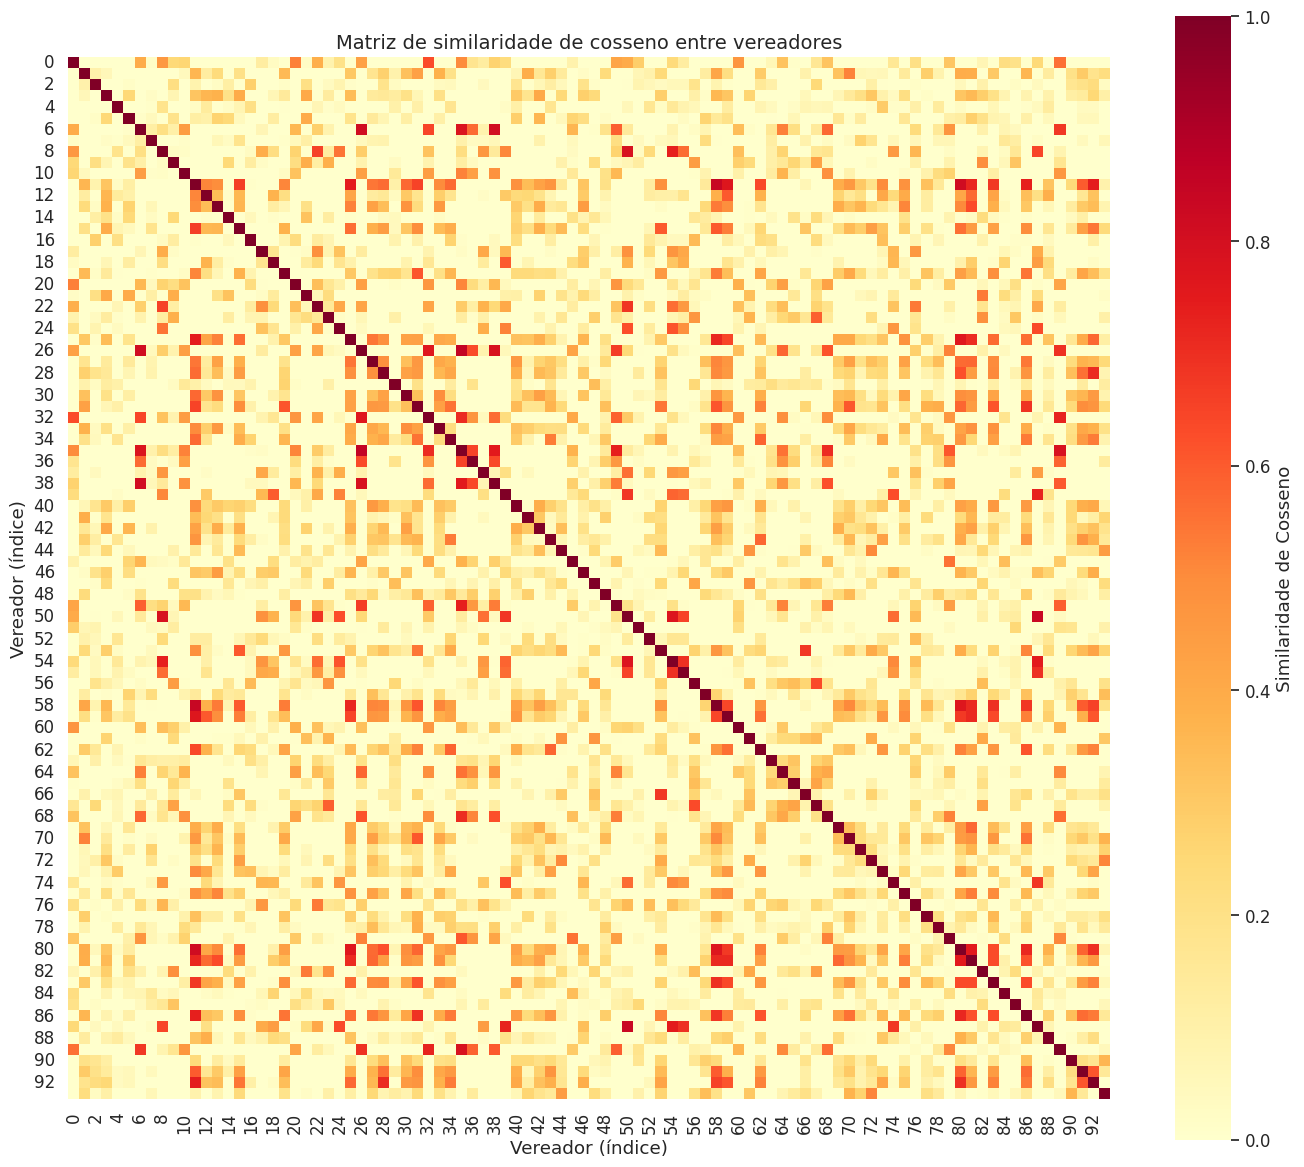

In [39]:
# heatmap da matriz de similaridade de cosseno
# cores mais quentes indicam maior similaridade entre vereadores

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    sim_matrix,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    square=True,
    cbar_kws={"label": "Similaridade de Cosseno"},
    ax=ax,
)
ax.set_title("Matriz de similaridade de cosseno entre vereadores", fontsize=14)
ax.set_xlabel("Vereador (índice)")
ax.set_ylabel("Vereador (índice)")
plt.tight_layout()
plt.show()

Agora o espaço vetorial está perfeitamente calibrado e pronto para gerar recomendações precisas, confiáveis e livres de ruído.


In [40]:
# top 10 pares de vereadores mais similares
# extraímos apenas o triângulo superior da matriz para evitar duplicatas

# pega os índices do triângulo superior (sem a diagonal)
i_upper, j_upper = np.triu_indices_from(sim_matrix, k=1)
similaridades = sim_matrix[i_upper, j_upper]

# ordena por similaridade decrescente
ordem = np.argsort(-similaridades)

print("TOP 10 PARES DE VEREADORES MAIS SIMILARES")
print(f"{'Vereador 1':<30} {'Vereador 2':<30} {'Similaridade':>12}")
print("-" * 70)

for rank in range(10):
    idx = ordem[rank]
    i, j = i_upper[idx], j_upper[idx]
    nome_i = metadata.iloc[i]["nome"]
    nome_j = metadata.iloc[j]["nome"]
    mun_i = metadata.iloc[i]["municipio"]
    mun_j = metadata.iloc[j]["municipio"]
    sim = similaridades[idx]
    print(f"{nome_i} ({mun_i})")
    print(f"  × {nome_j} ({mun_j})  →  {sim:.4f}")
    print()

TOP 10 PARES DE VEREADORES MAIS SIMILARES
Vereador 1                     Vereador 2                     Similaridade
----------------------------------------------------------------------
França (Bayeux)
  × Jays de Nita (Bayeux)  →  0.8552

Carlão (João Pessoa)
  × Milanez Neto (João Pessoa)  →  0.8407

Marco Cesar Souza Siqueira (Patos)
  × Valtide Paulino Santos (Patos)  →  0.8335

Carlão (João Pessoa)
  × Saulo Germano (Campina Grande)  →  0.8153

Berguinho Impacto Som (Bayeux)
  × França (Bayeux)  →  0.8125

Berguinho Impacto Som (Bayeux)
  × Josauro Pereira (Bayeux)  →  0.8053

Brenna Victoria Leonardo Ferreira Nobreg (Patos)
  × Marco Cesar Souza Siqueira (Patos)  →  0.7881

França (Bayeux)
  × Josauro Pereira (Bayeux)  →  0.7870

Jays de Nita (Bayeux)
  × Wagner do Grau (Bayeux)  →  0.7864

Berguinho Impacto Som (Bayeux)
  × Jays de Nita (Bayeux)  →  0.7793



O ranking reflete afinidades políticas e temáticas legítimas e localizadas, mapeando blocos de atuação intensa em Bayeux e Patos, além de conexões intermunicipais relevantes como João Pessoa e Campina Grande. Geometricamente, as distâncias carregam significado real, o que valida o motor de recomendação como pronto e confiável para extrair os perfis políticos.


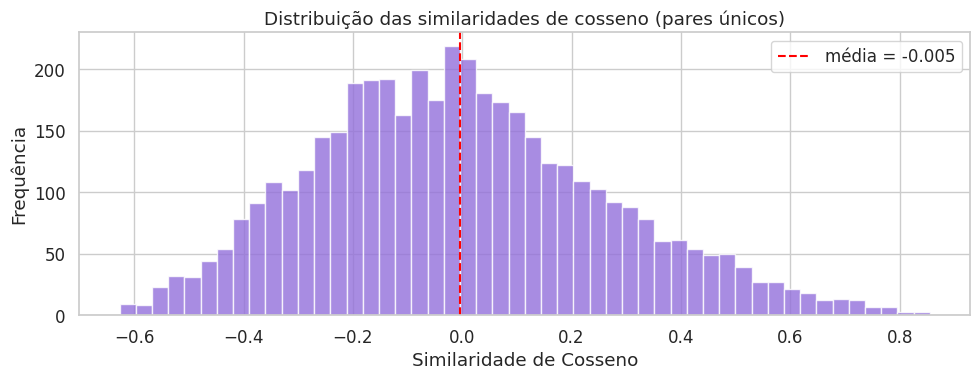

In [43]:
# distribuição de todas as similaridades (pares únicos)
# ajuda a entender se os vereadores são em geral similares ou diversos

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similaridades, bins=50, color="mediumpurple", edgecolor="white", alpha=0.8)
ax.axvline(similaridades.mean(), color="red", linestyle="--", 
           label=f"média = {similaridades.mean():.3f}")
ax.set_title("Distribuição das similaridades de cosseno (pares únicos)")
ax.set_xlabel("Similaridade de Cosseno")
ax.set_ylabel("Frequência")
ax.legend()
plt.tight_layout()
plt.show()

Em resumo, a curva de perda mostra que o treino do autoencoder funcionou. O modelo convergiu rápido, sem oscilações e estabilizou logo nas primeiras épocas. Esse comportamento mostra que a taxa de aprendizado e o tamanho do batch estavam bem calibrados para os novos dados filtrados. A rede comprimiu as pautas perfeitamente e os embeddings de 64 dimensões estão prontos para o sistema de recomendação.


---

## 6. Visualização 2D — PCA


In [44]:
# PCA -> reduz os embeddings de 768 para 2 dimensões
# útil para uma visualização rápida da estrutura dos dados
# a variância explicada indica quanto da informação original é preservada

pca = PCA(n_components=2, random_state=42)
emb_pca = pca.fit_transform(embeddings)

var_explicada = pca.explained_variance_ratio_
print(f"Variância explicada pelo PC1: {var_explicada[0]:.2%}")
print(f"Variância explicada pelo PC2: {var_explicada[1]:.2%}")
print(f"Variância total (2 componentes): {var_explicada.sum():.2%}")

Variância explicada pelo PC1: 23.09%
Variância explicada pelo PC2: 10.42%
Variância total (2 componentes): 33.51%


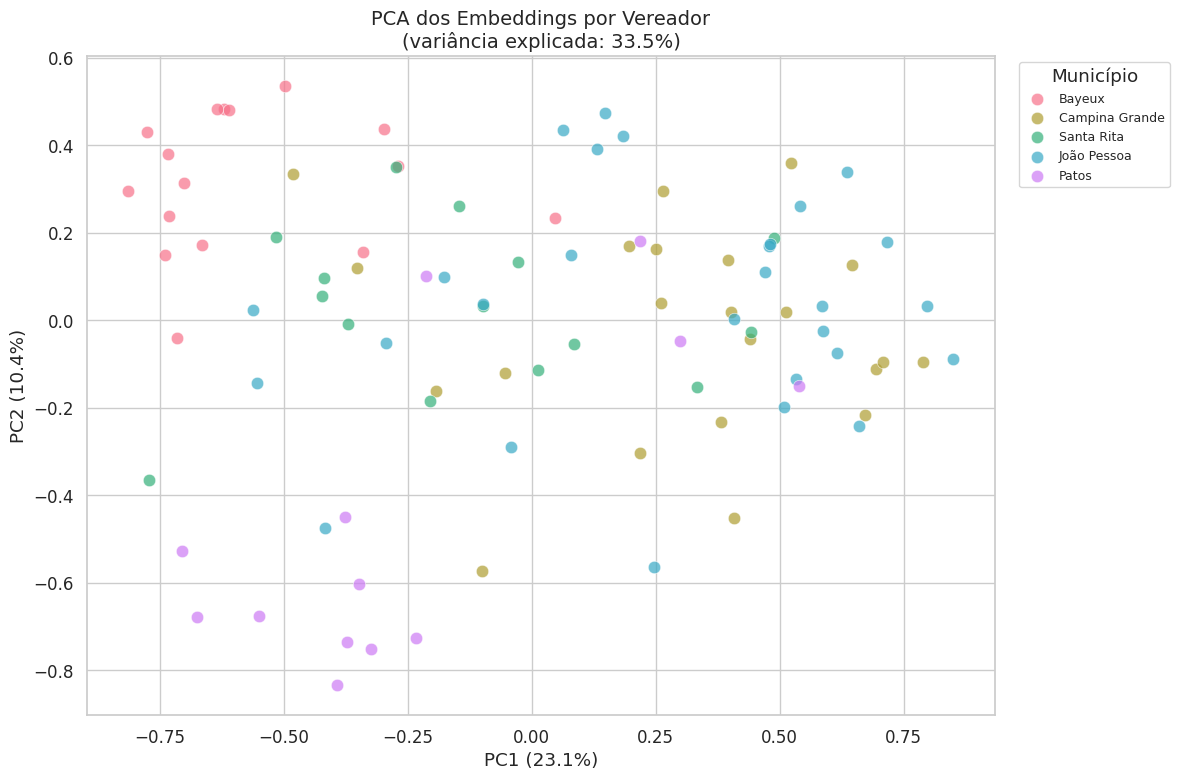

In [45]:
# scatter plot PCA colorido por município
# cada ponto é um vereador, a cor indica o município

fig, ax = plt.subplots(figsize=(12, 8))

municipios = metadata["municipio"].unique()
cores = sns.color_palette("husl", len(municipios))

for mun, cor in zip(municipios, cores):
    mask = metadata["municipio"] == mun
    ax.scatter(
        emb_pca[mask, 0], emb_pca[mask, 1],
        label=mun, color=cor, s=80, alpha=0.7, edgecolors="white", linewidth=0.5
    )

ax.set_title(f"PCA dos Embeddings por Vereador\n(variância explicada: {var_explicada.sum():.1%})", fontsize=14)
ax.set_xlabel(f"PC1 ({var_explicada[0]:.1%})")
ax.set_ylabel(f"PC2 ({var_explicada[1]:.1%})")
ax.legend(title="Município", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

O gráfico do PCA demonstra que o agrupamento espacial é guiado por afinidades temáticas e não só por proximidade geográfica. A forte sobreposição entre os parlamentares de João Pessoa, Campina Grande e Santa Rita prova que o viés municipal foi mitigado, permitindo conexões baseadas em pautas ideológicas compartilhadas. Por outro lado, o isolamento do bloco de Patos no quadrante inferior esquerdo e a forte polarização de Bayeux ao longo do PC1 expõem assinaturas políticas locais bem definidas, validando o mapa como uma representação fiel e altamente discriminativa do cenário intermunicipal.


---

## 7. Visualização 2D — t-SNE


In [53]:
# t-SNE -> redução de dimensionalidade não-linear
# melhor que PCA para capturar estruturas locais (clusters)
# perplexity controla o equilíbrio entre estrutura local e global
# valores baixos (5-15) enfatizam clusters locais
# valores altos (30-50) mostram mais a estrutura global

tsne = TSNE(
    n_components=2,
    perplexity=15,        # valor baixo por causa do dataset pequeno (97 vereadores)
    random_state=42,
    max_iter=1000,
    learning_rate="auto",
    init="pca",           # inicialização com PCA para estabilidade
)
emb_tsne = tsne.fit_transform(embeddings)

print(f"t-SNE concluído. Shape: {emb_tsne.shape}")

t-SNE concluído. Shape: (94, 2)


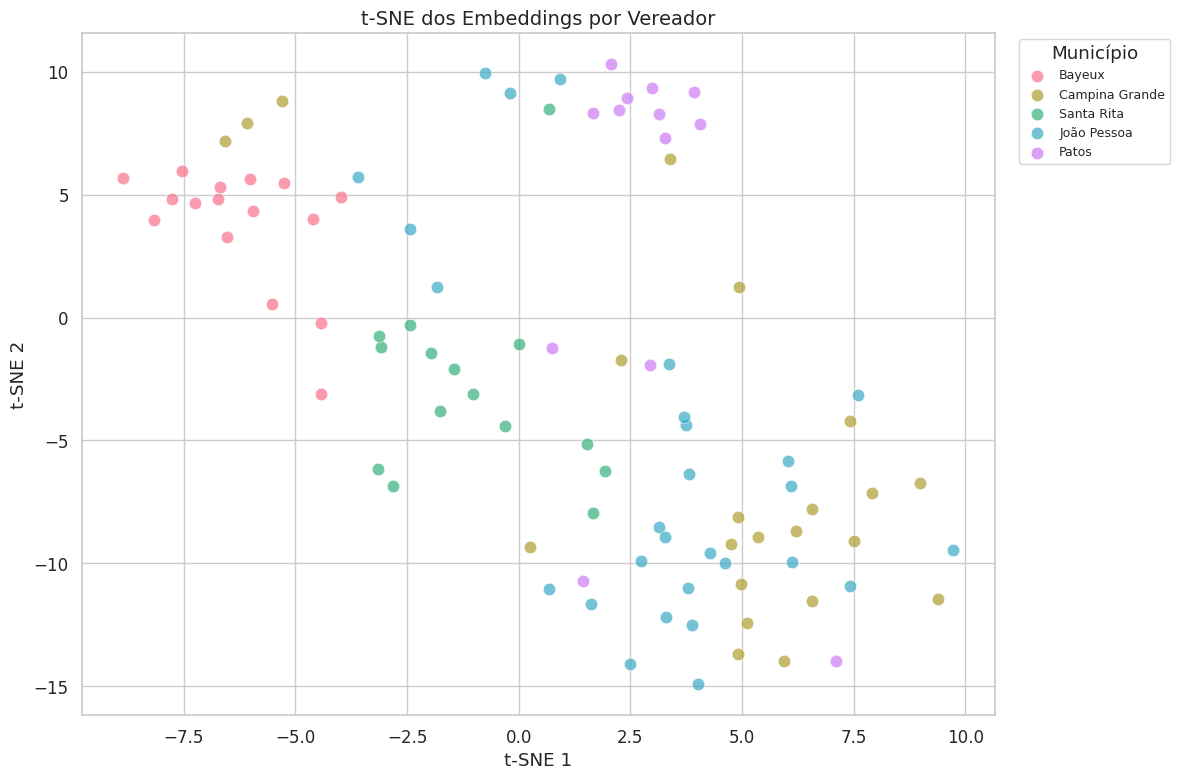

In [54]:
# scatter plot t-SNE colorido por município
# t-SNE tende a formar clusters mais visíveis que PCA

fig, ax = plt.subplots(figsize=(12, 8))

for mun, cor in zip(municipios, cores):
    mask = metadata["municipio"] == mun
    ax.scatter(
        emb_tsne[mask, 0], emb_tsne[mask, 1],
        label=mun, color=cor, s=80, alpha=0.7, edgecolors="white", linewidth=0.5
    )

ax.set_title("t-SNE dos Embeddings por Vereador", fontsize=14)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(title="Município", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

---

## 8. Distribuição por município


In [55]:
# conta quantos vereadores existem por município nos metadados

contagem = metadata["municipio"].value_counts()

print("VEREADORES POR MUNICÍPIO\n")

for mun, count in contagem.items():
    print(f"  {mun:<25} {count:>3}")
print(f"{'TOTAL':<25} {contagem.sum():>5}")

VEREADORES POR MUNICÍPIO

  João Pessoa                28
  Campina Grande             22
  Bayeux                     16
  Santa Rita                 15
  Patos                      13
TOTAL                        94


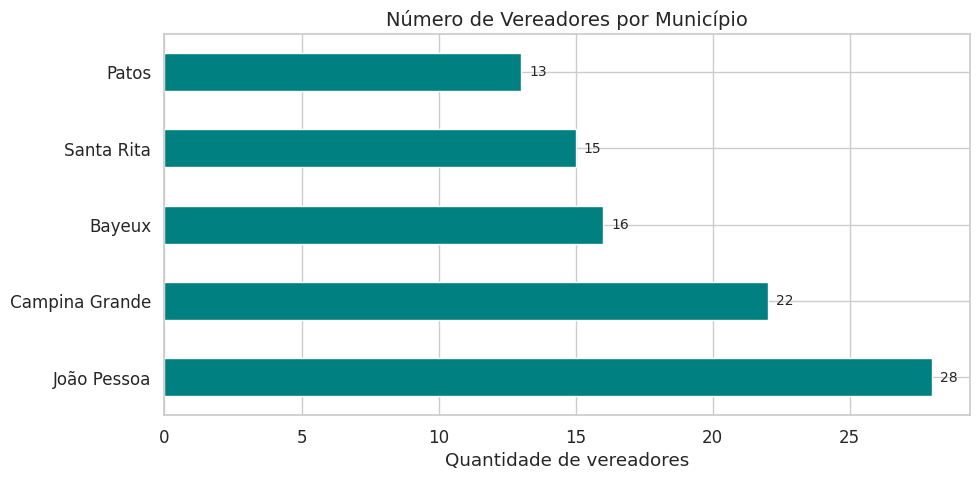

In [56]:
# gráfico de barras — vereadores por município

fig, ax = plt.subplots(figsize=(10, 5))
contagem.plot(kind="barh", color="teal", edgecolor="white", ax=ax)
ax.set_title("Número de Vereadores por Município", fontsize=14)
ax.set_xlabel("Quantidade de vereadores")
ax.set_ylabel("")

# adiciona os valores nas barras
for i, v in enumerate(contagem.values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.show()

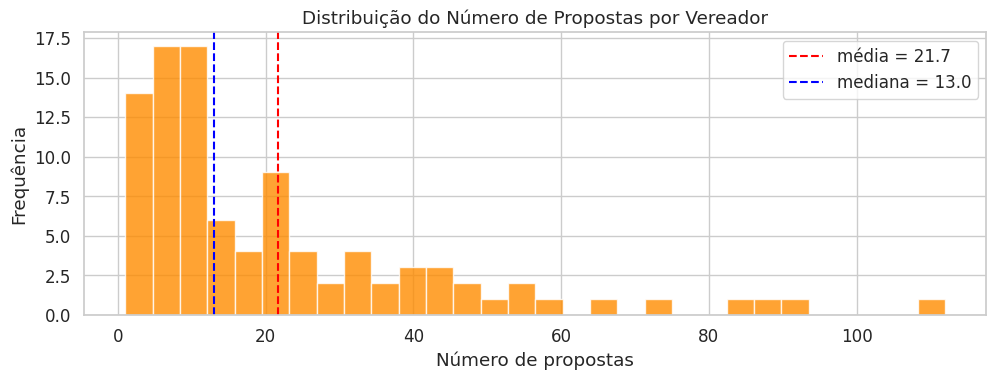

Mínimo de propostas:  1
Máximo de propostas:  112
Média de propostas:   21.7
Mediana de propostas: 13.0


In [51]:
# propostas por vereador no dataset original
# verifica a distribuição do número de propostas usadas para gerar cada embedding

propostas_por_vereador = df_original.groupby("vereador").size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(propostas_por_vereador.values, bins=30, color="darkorange", edgecolor="white", alpha=0.8)
ax.axvline(propostas_por_vereador.mean(), color="red", linestyle="--",
           label=f"média = {propostas_por_vereador.mean():.1f}")
ax.axvline(propostas_por_vereador.median(), color="blue", linestyle="--",
           label=f"mediana = {propostas_por_vereador.median():.1f}")
ax.set_title("Distribuição do Número de Propostas por Vereador")
ax.set_xlabel("Número de propostas")
ax.set_ylabel("Frequência")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mínimo de propostas:  {propostas_por_vereador.min()}")
print(f"Máximo de propostas:  {propostas_por_vereador.max()}")
print(f"Média de propostas:   {propostas_por_vereador.mean():.1f}")
print(f"Mediana de propostas: {propostas_por_vereador.median():.1f}")

A forte centralização e mistura entre João Pessoa, Campina Grande e Santa Rita prova que o modelo identificou um núcleo comum de pautas urbanas compartilhadas. Ao mesmo tempo, o fato de Bayeux e Patos ainda manterem suas próprias concentrações nas extremidades valida que a compressão de 64 dimensões preservou as caracteristicas regionais mais autênticas e marcantes de cada município, deixando a recomendação bem calibrada.


---

## 9. Variância Explicada — PCA Completo


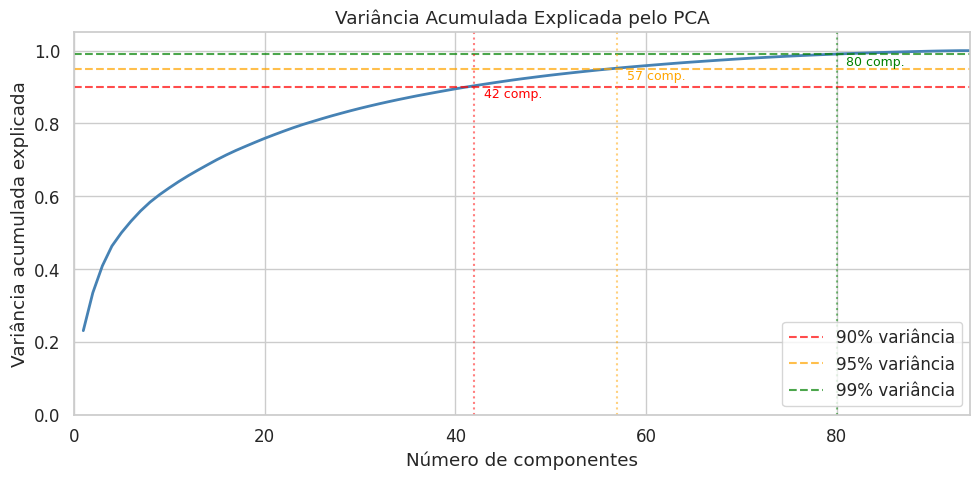

Componentes para 90% da variância: 42
Componentes para 95% da variância: 57
Componentes para 99% da variância: 80
Total de componentes: 94


In [58]:
# PCA com todos os componentes para analisar a variância acumulada
# indica quantas dimensões são necessárias para capturar X% da informação
# útil para escolher a dimensão do espaço latente do autoencoder

pca_full = PCA(random_state=42)
pca_full.fit(embeddings)

var_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(var_acumulada) + 1), var_acumulada, color="steelblue", linewidth=2)
ax.axhline(0.90, color="red", linestyle="--", alpha=0.7, label="90% variância")
ax.axhline(0.95, color="orange", linestyle="--", alpha=0.7, label="95% variância")
ax.axhline(0.99, color="green", linestyle="--", alpha=0.7, label="99% variância")

# marca o número de componentes para 90%, 95% e 99%
for threshold, cor in [(0.90, "red"), (0.95, "orange"), (0.99, "green")]:
    n_comp = np.searchsorted(var_acumulada, threshold) + 1
    ax.axvline(n_comp, color=cor, linestyle=":", alpha=0.5)
    ax.text(n_comp + 1, threshold - 0.03, f"{n_comp} comp.", fontsize=9, color=cor)

ax.set_title("Variância Acumulada Explicada pelo PCA")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Variância acumulada explicada")
ax.legend(loc="lower right")
ax.set_xlim(0, len(var_acumulada))
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"Componentes para 90% da variância: {np.searchsorted(var_acumulada, 0.90) + 1}")
print(f"Componentes para 95% da variância: {np.searchsorted(var_acumulada, 0.95) + 1}")
print(f"Componentes para 99% da variância: {np.searchsorted(var_acumulada, 0.99) + 1}")
print(f"Total de componentes: {len(var_acumulada)}")

O comportamento político e temático dos vereadores é altamente multidimensional, exigindo 42 componentes para reter 90% da variância e 80 componentes para atingir 99%. Essa distribuição justifica perfeitamente a escolha de 64 dimensões para o espaço latente do autoencoder, provando matematicamente que essa taxa de compressão preserva mais de 95% da informação essencial do dataset, eliminando ruídos e garantindo vetores altamente ricos e eficientes para o motor de recomendação.
